# 03 — CNN baseline
**Classificação de gênero musical — GTZAN / CNN sobre espectrogramas Mel**

Treina a **CNN baseline** (construída do zero) sobre os espectrogramas Mel de 3 s gerados
no notebook 02. Estabelece a primeira referência de desempenho — acurácia e **F1-score
macro** — contra a qual o modelo de transferência de aprendizado (notebook 04) será
comparado.

In [1]:
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src import config as C
from src import preprocess, models, evaluate

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
models.set_seeds(C.SEED)

## 1. Dados

Carregamos os arrays Mel já em cache (segundos) e convertemos para `float32` para o treino.

In [2]:
mel = preprocess.load_dataset("mel")
Xtr, ytr = mel["train"][0].astype(np.float32), mel["train"][1]
Xva, yva = mel["val"][0].astype(np.float32), mel["val"][1]
Xte, yte = mel["test"][0].astype(np.float32), mel["test"][1]
print("treino:", Xtr.shape, "| val:", Xva.shape, "| teste:", Xte.shape)

treino: (6985, 128, 130, 1) | val: (1499, 128, 130, 1) | teste: (1497, 128, 130, 1)


## 2. Arquitetura

Três blocos Conv–BatchNorm–MaxPool, *global average pooling* e cabeça densa com dropout.
O *global pooling* mantém o número de parâmetros baixo, ajudando contra overfitting numa
base pequena.

In [3]:
model = models.build_baseline_cnn(learning_rate=5e-4)
model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,474 (431.54 KB)

 Trainable params: 110,474 (431.54 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Treinamento

Adam (lr=1e-3), perda *sparse categorical crossentropy*. Callbacks: *early stopping* (com
restauração dos melhores pesos) e redução de learning rate em platô.

> **Treino em CPU é lento (~1 min/época).** Para evitar reexecuções custosas, o modelo
> treinado e o histórico são salvos em `models/` e reaproveitados (padrão *carregar-ou-treinar*).
> Para forçar um novo treino, apague `models/baseline_cnn.keras`.

In [4]:
import json
from tensorflow import keras

MODEL_PATH = C.MODELS_DIR / "baseline_cnn.keras"
HIST_PATH = C.MODELS_DIR / "baseline_history.json"

if MODEL_PATH.exists() and HIST_PATH.exists():
    print("Modelo em cache encontrado — carregando.")
    model = keras.models.load_model(MODEL_PATH)
    history = json.loads(HIST_PATH.read_text())
else:
    print("Treinando do zero (pode levar ~20-30 min em CPU)...")
    h = model.fit(
        Xtr, ytr, validation_data=(Xva, yva),
        epochs=30, batch_size=128,
        callbacks=models.default_callbacks(patience=6), verbose=2,
    )
    history = h.history
    model.save(MODEL_PATH)
    evaluate.save_history(h, HIST_PATH)
print("Épocas registradas:", len(history["loss"]))

Modelo em cache encontrado — carregando.


Épocas registradas: 30


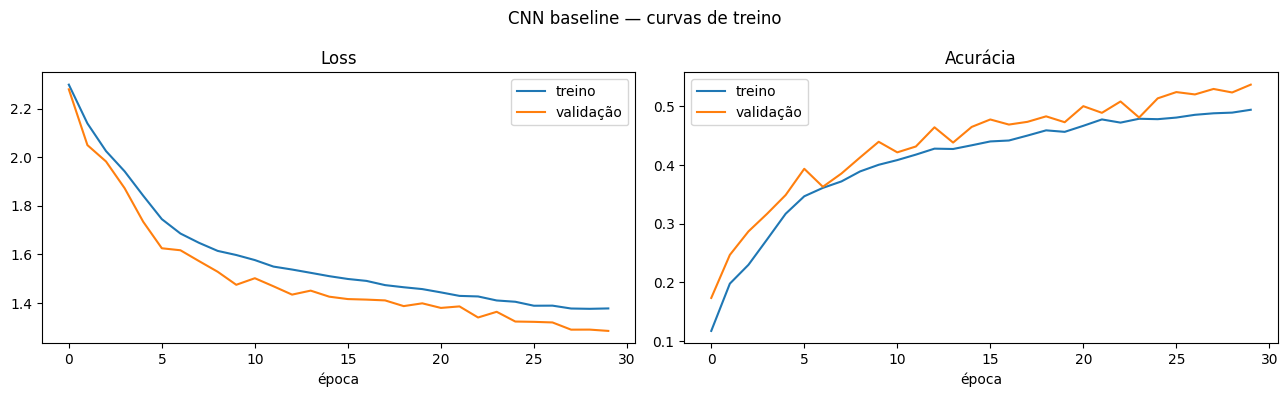

In [5]:
evaluate.plot_history(history, title="CNN baseline — curvas de treino")
plt.show()

## 4. Avaliação no conjunto de teste

Métricas no nível de **segmento de 3 s** (cada segmento é classificado independentemente).

In [6]:
res = evaluate.evaluate_model(model, Xte, yte)
print(f"Acurácia (teste): {res['accuracy']:.4f}")
print(f"F1 macro (teste): {res['f1_macro']:.4f}\n")
evaluate.print_report(yte, res["y_pred"])

Acurácia (teste): 0.5504
F1 macro (teste): 0.5332

              precision    recall  f1-score   support

       blues      0.434     0.633     0.515       150
   classical      0.708     0.812     0.756       149
     country      0.435     0.544     0.484       149
       disco      0.471     0.220     0.300       150
      hiphop      0.567     0.685     0.620       149
        jazz      0.321     0.227     0.266       150
       metal      0.745     0.820     0.781       150
         pop      0.697     0.813     0.751       150
      reggae      0.536     0.347     0.421       150
        rock      0.477     0.407     0.439       150

    accuracy                          0.550      1497
   macro avg      0.539     0.551     0.533      1497
weighted avg      0.539     0.550     0.533      1497



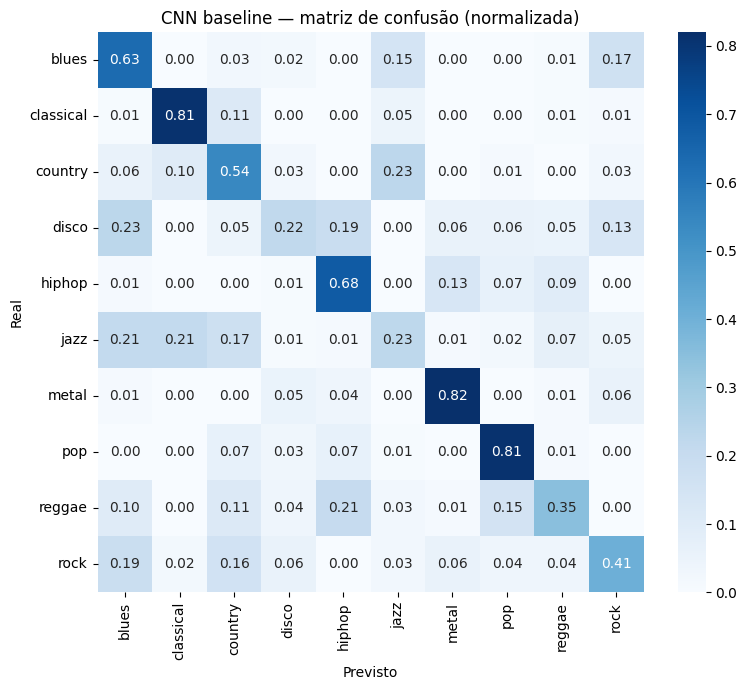

In [7]:
evaluate.plot_confusion_matrix(yte, res["y_pred"], normalize=True,
                               title="CNN baseline — matriz de confusão (normalizada)")
plt.show()

## 5. Registrar resultados

O modelo (`baseline_cnn.keras`) e o histórico já foram salvos no treino. Aqui apenas
registramos as métricas de teste na tabela compartilhada `models/results.json`, usada na
comparação final (notebook 05).

In [8]:
table = evaluate.append_result("baseline_cnn (mel 3s)", res["accuracy"], res["f1_macro"])
print("Tabela de resultados acumulada:")
for k, v in table.items():
    print(f"  {k}: acc={v['accuracy']:.4f}, f1={v['f1_macro']:.4f}")

Tabela de resultados acumulada:
  baseline_cnn (mel 3s): acc=0.5504, f1=0.5332


## 6. Síntese

A CNN baseline estabelece a referência de desempenho do projeto. Pontos a observar:

- Diferença entre acurácia de treino e validação indica o grau de **overfitting**.
- A matriz de confusão revela quais gêneros mais se confundem (esperado: rock/country/disco,
  conforme antecipado na EDA).

**Próximo passo:** `04_transfer_learning.ipynb` — usar um modelo pré-treinado na ImageNet
sobre os mesmos espectrogramas e comparar com esta baseline.